# IMDb Sentiment Analysis 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.columns = ['review_text', 'sentiment']

In [5]:
print("=== Dataset Overview ===")
print(df.info(), "\n")
print("Sample Data:")
print(df.head(), "\n")

=== Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  50000 non-null  object
 1   sentiment    50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None 

Sample Data:
                                         review_text sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive 



In [6]:
print("Sentiment Value Samples:")
print(df['sentiment'].unique())

Sentiment Value Samples:
['positive' 'negative']


In [7]:
print("\n[S1] Chart Type Determined: BAR and PIE charts suitable for sentiment distribution.")


[S1] Chart Type Determined: BAR and PIE charts suitable for sentiment distribution.


In [8]:
# Selecting only relevant columns and deriving review length
df['review_length'] = df['review_text'].str.len()

print("\n[S2] Derived Feature Created: review_length (character count)")
print(df[['review_text', 'review_length', 'sentiment']].head(3))


[S2] Derived Feature Created: review_length (character count)
                                         review_text  review_length sentiment
0  One of the other reviewers has mentioned that ...           1761  positive
1  A wonderful little production. <br /><br />The...            998  positive
2  I thought this was a wonderful way to spend ti...            926  positive


In [9]:
df.describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


In [10]:
# Grouping by sentiment and calculating both counts and average length
df_grouped = df.groupby('sentiment').agg(
    ReviewCount=('review_text', 'count'),
    AvgLength=('review_length', 'mean')
).reset_index()

print("\n[S3] Data Grouped by Sentiment:")
print(df_grouped, "\n")


[S3] Data Grouped by Sentiment:
  sentiment  ReviewCount   AvgLength
0  negative        25000  1294.06436
1  positive        25000  1324.79768 



In [11]:
# Sorting by ReviewCount (optional but for better readability)
df_final = df_grouped.sort_values(by='ReviewCount', ascending=False)

print("[S4] Data Refined for Visualization:")
print(df_final)

[S4] Data Refined for Visualization:
  sentiment  ReviewCount   AvgLength
0  negative        25000  1294.06436
1  positive        25000  1324.79768


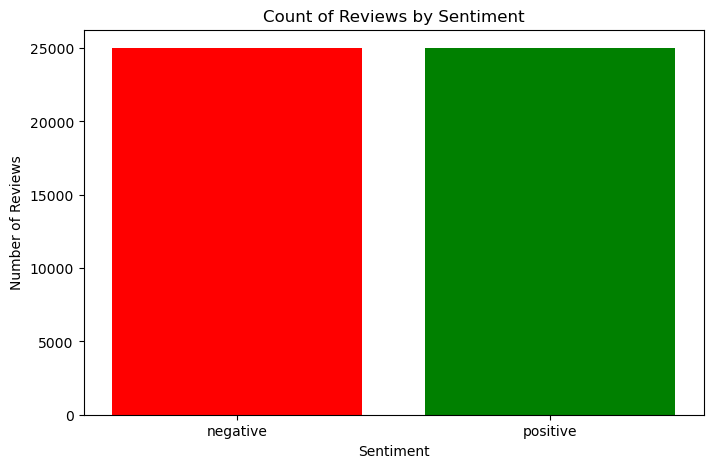

In [12]:
# BAR CHART: Count of Reviews by Sentiment
plt.figure(figsize=(8, 5))
plt.bar(df_final['sentiment'], df_final['ReviewCount'], color=['red', 'green'])
plt.title('Count of Reviews by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

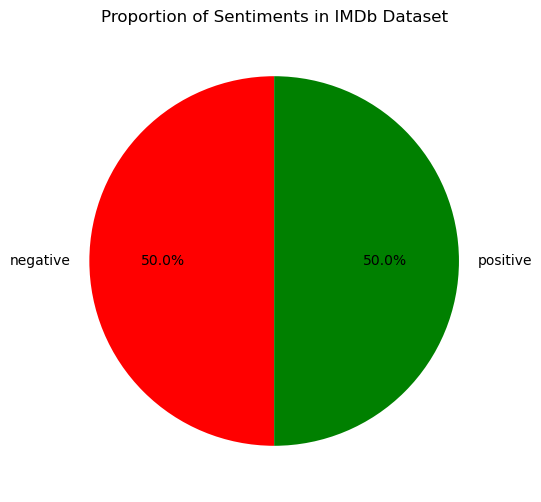

In [13]:
# PIE CHART: Proportion of Reviews by Sentiment
plt.figure(figsize=(6, 6))
plt.pie(df_final['ReviewCount'], labels=df_final['sentiment'], autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title('Proportion of Sentiments in IMDb Dataset')
plt.show()

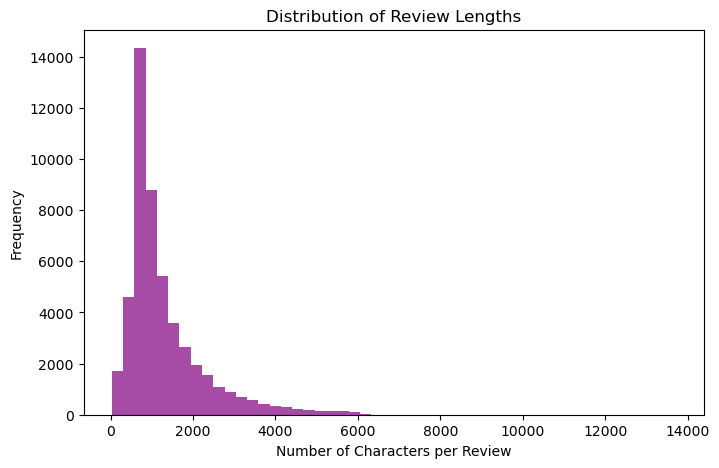

In [14]:
# HISTOGRAM: Distribution of Review Lengths
plt.figure(figsize=(8, 5))
df['review_length'].plot(kind='hist', bins=50, color='purple', alpha=0.7)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters per Review')
plt.ylabel('Frequency')
plt.show()